<h1 style="color: green;">6.1</h1>

Filename: /Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530

This data structure is a: <class 'numpy.ndarray'>
Its shape should be (NAXIS2, NAXIS1): (530, 530)
(NAXIS2, NAXIS1) are: 530 530
Number of bytes (1byte = 8 bits): >i2 

N=280900 min=1507, max=15752, mean=4795.924268422927, std=1848.2558984219054, Mode: 3551 with 876 counts, Median: 4102.0


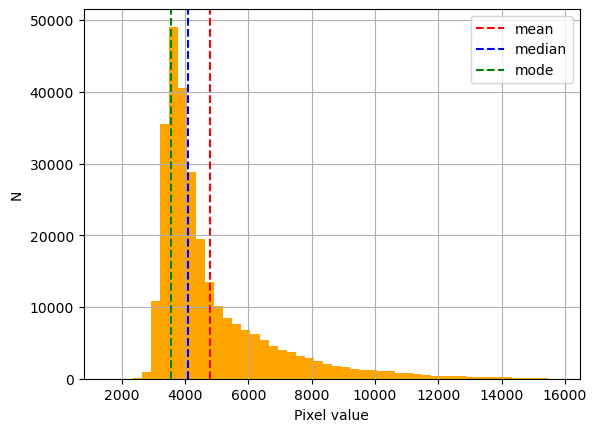

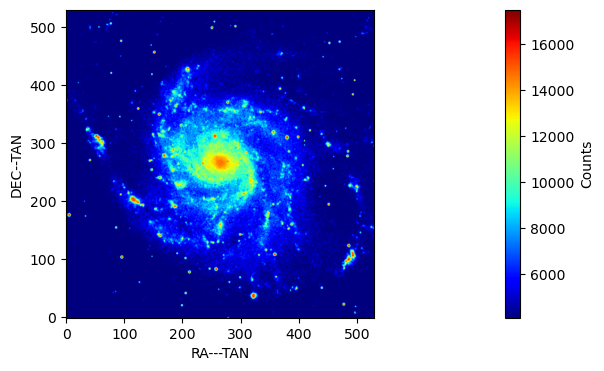

 [astropy.io.fits.verify]


In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt


hdulist = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits')
hdulist.info()
 # number of HDUs: 2
 # HDU nr of data: 1st
 # number type :int16
    
hdr = hdulist[0].header



for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
 # Bitpix gives 16 which corresponds to the int16 from before


dat = hdulist[0].data
print("\nThis data structure is a:", type(dat))
print("Its shape should be (NAXIS2, NAXIS1):", dat.shape)
print("(NAXIS2, NAXIS1) are:", hdr['NAXIS2'], hdr['NAXIS1'])
print("Number of bytes (1byte = 8 bits):",dat.dtype,'\n')


from scipy import stats

flatdat = dat.flatten()
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(flatdat)
mode, counts = stats.mode(flatdat)
median = np.median(flatdat)
print(f"N={nobs} min={minval}, max={maxval}, mean={mean}, std={var**0.5}, Mode: {mode} with {counts} counts, Median: {median}")



from matplotlib.pyplot import figure, show
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(flatdat, bins=50, color="orange")
frame.grid()
frame.set_xlabel("Pixel value")
frame.set_ylabel("N")
frame.axvline(mean, ls='--', color='r', label = 'mean')
frame.axvline(median, ls='--', color='b', label = 'median')
frame.axvline(mode, ls='--', color='g', label = 'mode')
frame.legend()

array = np.asarray(dat)
medianar = np.median(array)

from matplotlib.pyplot import figure, show

fig = figure(figsize=(115,4))
frame = fig.add_subplot(1,3,1)
plt.imshow(array, origin="lower", cmap='jet', vmin=median, vmax=17500)
frame.set_xlabel(hdr["CTYPE1"])
frame.set_ylabel(hdr["CTYPE2"])

hdr['BUNIT'] = 'Counts'

plt.colorbar(label = hdr['BUNIT'])
plt.show()


hdulistout = fits.PrimaryHDU(array)
hdulistout.header = hdr    # We can copy the old header
hdulistout.writeto('New.fits', overwrite=True, output_verify='ignore')



hdulist.close()



<h1 style="color: black;">6.2</h1>

<h1 style="color: green;">6.3</h1>

In [3]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show
import math

hdulist = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits')

hdulist.info()
dat = hdulist[0].data
dataa = np.asarray(dat, dtype = float )
data = dataa[:20,:20]


xRMS = ((1/400) * (np.sum(data**2)))**0.5
print(xRMS,np.mean(data))
mean = np.mean(data)
stdev = np.std(data)
print(mean,stdev)

# xRMS is better because it considers the mean, since noise are extremes above or below the mean we need the xrms for that and not the std

Filename: /Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
3432.752866505248 3422.8825
3422.8825 260.1300322795313


<h1 style="color: green;">6.5</h1>

9.984015566794838 10.003955116338462 9.995349488722518
5.773191380233297
5.770294583366141


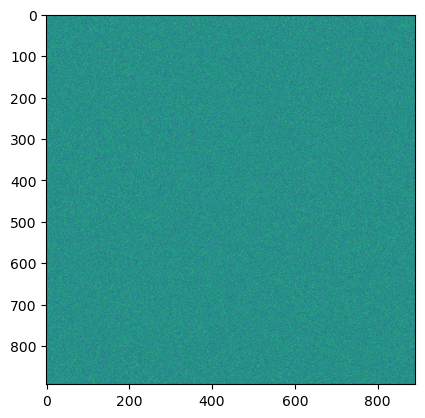

In [4]:
map0 = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/noisemap0.fits')
map1 = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/noisemap1.fits')
map2 = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/noisemap2.fits')

dat0 = map0[0].data
dat1 = map1[0].data
dat2 = map2[0].data

stdev0 = np.std(dat0)
stdev1 = np.std(dat1)
stdev2 = np.std(dat2)
print(stdev0, stdev1, stdev2)

stacked = np.stack((dat0,dat1,dat2),axis=2)
#print(stacked)
meanstack = stacked.mean(axis=2)

fig = plt.figure()
plt.imshow(meanstack)

meanstackflat = meanstack.flatten()
stdstackflat = np.std(meanstackflat)
print(stdstackflat)

stdev = (1/3) * math.sqrt(stdev0**2 +stdev1**2+stdev2**2)
print(stdev)

<h1 style="color: red;">6.6</h1>

In [8]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

# Open the FITS file
hdul = fits.open('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table

# List of the column names
colnames = hdul[1].columns.names
print(colnames)

# An image fits file will contain info in the shape of 'pixels' so just numbers basically
# A table fits file will contain a structured table with headers etc
# For an image you have pixels in the extension and for a table its columns and rows

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

table = Table(data)

# Compute distance in parsecs
distance_pc = 1000 / table['GAIAEDR3_PARALLAX']

# Add new columns directly to the table
table['DATAFLAG'] = mask.astype(int) # will make the mask (true, false) into a integer list(0, 1) and add it as a column
table['ABS_MAG_G'] = np.where(mask,table['GAIAEDR3_PHOT_G_MEAN_MAG'] - 5 * np.log10(distance_pc),  -1.0)
# If condition is met calculate the absolute magnitude and if its not met then make the value -1

# Write the table to a new FITS file
table.write('APOGEE_update.fits', overwrite=True)
hdul.close()

['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']


/tmp/ipykernel_1482718/4185665888.py:36: RuntimeWarning: invalid value encountered in log10
  table['ABS_MAG_G'] = np.where(mask,table['GAIAEDR3_PHOT_G_MEAN_MAG'] - 5 * np.log10(distance_pc),  -1.0)


<h1 style="color: red;">6.7</h1>

Maximum flux: 42489404.0
Row corresponding to maximum flux:
     source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
Average m0: 25.68840037029544


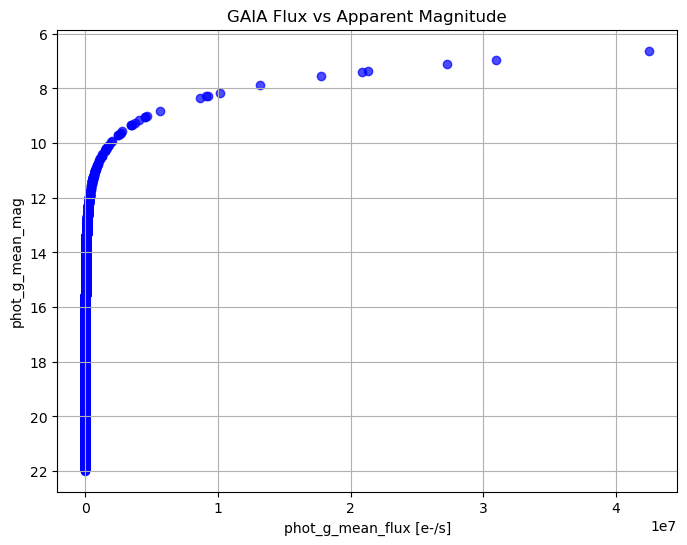

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the csv file with panda (turns it into a dataframe, excel in python basically)
file = pd.read_csv('/Users/users/amvecht/PROGNUM-repo/TASK6/Extra files/gaiaTestData.csv')

# max flux from file (from specific column)
max_flux = file['phot_g_mean_flux'].max()
# row of max flux (Boolean indexing) returns true or false so all rows with true are returned
max_flux_row = file[file['phot_g_mean_flux'] == max_flux]
# Print the values and row of the max flux
print("Maximum flux:", max_flux)
print("Row corresponding to maximum flux:\n", max_flux_row)

# sort the whole file by the column photgmeanflux from smallest to largest into a new dataframe
file_sorted = file.sort_values(by='phot_g_mean_flux', ascending=True)

# Calculate m0 for all and take the average
m0_values = file_sorted['phot_g_mean_mag'] + 2.5 * np.log10(file_sorted['phot_g_mean_flux'])
m0_avg = m0_values.mean()
print("Average m0:", m0_avg)

# Use values for x and y in a scatter plot (using the sorted file version)
plt.figure(figsize=(8,6))
plt.scatter(file_sorted['phot_g_mean_flux'], file_sorted['phot_g_mean_mag'], color='blue', alpha=0.7)
plt.xlabel('phot_g_mean_flux [e-/s]')
plt.ylabel('phot_g_mean_mag')
plt.title('GAIA Flux vs Apparent Magnitude')
plt.gca().invert_yaxis()  # Magnitude scale is inverted (bright stars on top)
plt.grid(True)
plt.show()



<h1 style="color: black;">6.9</h1>

<h1 style="color: red;">6.10</h1>

In [10]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.table import Table

# use the top 2000 columns (less data to download) to find the requested columns (also including the give conditions)
query = """
SELECT TOP 10
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiaedr3.gaia_source
WHERE parallax/parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
order by random_index
"""

# use the query to get the requested columns from Gaia 
do = Gaia.launch_job(query) # sends query to 'database'
results = do.get_results() # returns found result from query

# Convert found table results to pandas DataFrame for easier further steps
file = results.to_pandas()

# Randomly select 50 rows in dataframe (use seed for same result every time)
filerando = file.sample(n=50, random_state=42)

# Make table and add the 50 random rows to a fits file
table = Table.from_pandas(filerando)
table.write("astroquery_gaia.fits", overwrite=True)

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


<h1 style="color: red;">6.14</h1>

In [17]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def __init__(self):
        self.sequence = [0, 1]
    def nth_term(self, N):
        """
        Returns the N-th Fibonacci number
        """
        for i in range(2,N+1):  # go untill the nth fib number is reached
            self.sequence.append(self.sequence[-1] + self.sequence[-2]) # add next fib number
        return self.sequence[N] # if N is reached print the Nth fib number (-1 as index also works to get the last value)

    def divisible_by(self, N, M):
        """
        Returns all Fibonacci numbers less than the N-th Fibonacci number
        that are divisible by M
        """
        fib_n = self.nth_term(N)  # compute N-th term
        divisible_list = [] # empty list
        a, b = 0, 1 # Starting values
        while a < fib_n: # if starting value is smaller than nth term (from previous method)
            if a % M == 0: # check if divideable
                divisible_list.append(a)
            a, b = b, a + b # calc new fib number
        return divisible_list

# Check with known values

fib = Fibonacci()

nth_100 = fib.nth_term(100)
print("100-th Fibonacci number:", nth_100)

div_by_7 = fib.divisible_by(100, 7)
print("Fibonacci numbers < 100-th term divisible by 7:")
print(div_by_7)

100-th Fibonacci number: 354224848179261915075
Fibonacci numbers < 100-th term divisible by 7:
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
